In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.2.2
numpy version: 2.0.2


In [6]:
df = pd.read_csv('marketing_AB.csv')
print("Shape:", df.shape)
df.head()

Shape: (169166, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130.0,Monday,20.0
1,1,1119715,ad,False,93.0,Tuesday,22.0
2,2,1144181,ad,False,21.0,Tuesday,18.0
3,3,1435133,ad,False,355.0,Tuesday,10.0
4,4,1015700,ad,False,276.0,Friday,14.0


In [11]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nInfo:")
df.info()
print("\nNulls:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nNumeric summary:\n", df.describe())
print("\nCategorical summary:\n", df.describe(include='object'))
print("\ntest group counts:\n", df['test group'].value_counts())
print("\ntest group split %:")
print(df['test group'].value_counts(normalize=True) * 100)

Shape: (169166, 6)

Dtypes:
 user_id             int64
test_group       category
converted          object
total_ads         float64
most_ads_day     category
most_ads_hour     float64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169166 entries, 0 to 169165
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   user_id        169166 non-null  int64   
 1   test_group     169165 non-null  category
 2   converted      169165 non-null  object  
 3   total_ads      169165 non-null  float64 
 4   most_ads_day   169165 non-null  category
 5   most_ads_hour  169165 non-null  float64 
dtypes: category(2), float64(2), int64(1), object(1)
memory usage: 5.5+ MB

Nulls:
 user_id          0
test_group       1
converted        1
total_ads        1
most_ads_day     1
most_ads_hour    1
dtype: int64

Duplicates: 0

Numeric summary:
             user_id      total_ads  most_ads_hour
count  1.691660e+05  

KeyError: 'test group'

In [12]:
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']


In [13]:
# converted_int
df['converted_int'] = df['converted'].astype(int)

# is_weekend
weekend_days = ['Saturday', 'Sunday']
df['is_weekend'] = df['most_ads_day'].isin(weekend_days).astype('int8')

# hour_period — ordered category
def hour_to_period(h):
    if 5 <= h < 12:
        return 'morning'
    elif 12 <= h < 17:
        return 'afternoon'
    elif 17 <= h < 21:
        return 'evening'
    else:
        return 'night'

df['hour_period'] = df['most_ads_hour'].apply(hour_to_period)

from pandas.api.types import CategoricalDtype
hour_cat = CategoricalDtype(categories=['morning','afternoon','evening','night'], ordered=True)
df['hour_period'] = df['hour_period'].astype(hour_cat)

# ads_bucket — fixed with duplicates='drop'
df['ads_bucket'] = pd.qcut(df['total_ads'], q=4, labels=['low','medium','high','very_high'], duplicates='drop')

df.head()

ValueError: cannot convert float NaN to integer

In [14]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory before: {mem_before:.2f} MB")

df['test_group'] = df['test_group'].astype('category')
df['most_ads_day'] = df['most_ads_day'].astype('category')
df['converted_int'] = df['converted_int'].astype('int8')
df['is_weekend'] = df['is_weekend'].astype('int8')
df['most_ads_hour'] = df['most_ads_hour'].astype('int8')
df['total_ads'] = pd.to_numeric(df['total_ads'], downcast='integer')

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory after: {mem_after:.2f} MB")
print(f"Reduction: {(1 - mem_after/mem_before)*100:.1f}%")

Memory before: 10.00 MB


KeyError: 'converted_int'

In [15]:
print("Final shape:", df.shape)
print("\nFinal dtypes:\n", df.dtypes)
print("\nFinal nulls:\n", df.isnull().sum())
print("Final duplicates:", df.duplicated().sum())

df.to_csv('marketing_AB_cleaned.csv', index=False)
print("\n✅ Saved as marketing_AB_cleaned.csv")

Final shape: (169166, 6)

Final dtypes:
 user_id             int64
test_group       category
converted          object
total_ads         float64
most_ads_day     category
most_ads_hour     float64
dtype: object

Final nulls:
 user_id          0
test_group       1
converted        1
total_ads        1
most_ads_day     1
most_ads_hour    1
dtype: int64
Final duplicates: 0

✅ Saved as marketing_AB_cleaned.csv


In [24]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [26]:
df = pd.read_csv("marketing_AB_cleaned.csv")

In [27]:
df.index.min()

0

In [28]:
df.index.max()

169165

In [29]:
df.columns

Index(['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')

In [32]:
df = df.dropna(subset=["converted"]).copy()

df["converted_int"] = df["converted"].astype(int)

In [33]:
df["test_group"].value_counts()

(df["test_group"].value_counts(normalize=True) * 100).round(2)

,proportion
test_group,
ad,94.73
psa,5.27


## Chi-Square Test
Evaluate whether conversion rates differ significantly between the Ads and PSA groups.

In [39]:
contingency = pd.crosstab(df["test_group"], df["converted_int"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

contingency
print("\nChi-square:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)


Chi-square: 73.54909791595622
Degrees of freedom: 1
P-value: 9.816378359592282e-18


**H₀:** Conversion rates are the same for both groups.  
**H₁:** Conversion rates are different between the two groups.

In [36]:
summary = df.groupby("test_group")["converted_int"].agg(
    conversions="sum",
    total="count"
)

summary["conversion_rate"] = (
    summary["conversions"] / summary["total"]
)

summary

,conversions,total,conversion_rate
test_group,,,
ad,7945,160243,0.049581
psa,263,8922,0.029478


## Cohen's h
Measure the practical effect size of the difference in conversion rates.

In [42]:
control_rate = summary.loc["psa", "conversion_rate"]
test_rate = summary.loc["ad", "conversion_rate"]

cohen_h = proportion_effectsize(control_rate, test_rate)

print("Cohen's h:", cohen_h)

Cohen's h: -0.1040090514887963


## 95% Confidence Interval
Estimate the range in which the true conversion rate for each group is likely to fall.

In [49]:
for group in summary.index:
    low, high = proportion_confint(
        count=summary.loc[group, "conversions"],
        nobs=summary.loc[group, "total"],
        alpha=0.05,
        method="wilson"
    )

    print(f"{group}:")
    print(f"95% CI = ({low:.4%}, {high:.4%})\n")

ad:
95% CI = (4.8529%, 5.0655%)

psa:
95% CI = (2.6165%, 3.3195%)



## Group Imbalance Analysis
Assess whether the unequal sample sizes between the Ads and PSA groups could impact the analysis.

## Statistical Power Analysis
Evaluate whether the experiment has sufficient power to detect a meaningful difference in conversion rates.

In [76]:
analysis = NormalIndPower()
effect_size = proportion_effectsize(control_rate, test_rate)
power = analysis.power(
    effect_size=effect_size,
    nobs1=summary.loc["psa", "total"],
    ratio=summary.loc["ad", "total"] / summary.loc["psa", "total"],
    alpha=0.05
)

print("Statistical Power:", power)

Statistical Power: 0.9999999999999853


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

## Dose-Response Curve
Analyze how conversion rate changes as the number of ads viewed increases.

In [78]:
dose_response = (
    df.groupby("total_ads")["converted_int"]
      .mean()
      .reset_index()
)

dose_response.head()

,total_ads,converted_int
0,1.0,0.008307
1,2.0,0.011149
2,3.0,0.009492
3,4.0,0.012161
4,5.0,0.009484


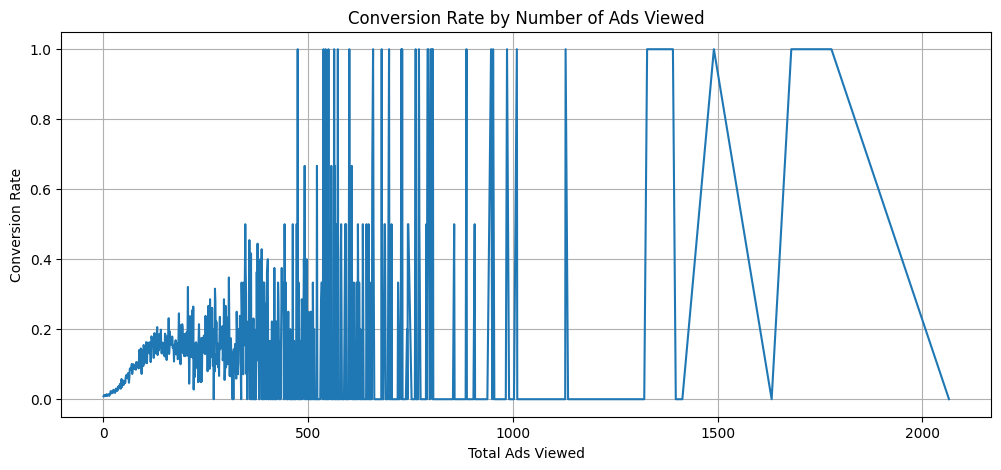

In [79]:
plt.figure(figsize=(12,5))

plt.plot(
    dose_response["total_ads"],
    dose_response["converted_int"],
)

plt.title("Conversion Rate by Number of Ads Viewed")
plt.xlabel("Total Ads Viewed")
plt.ylabel("Conversion Rate")

plt.grid(True)

plt.show()

## Hourly Conversion Analysis
Visualize conversion rates by hour to identify peak and low-performing time periods.

In [80]:
hourly_conversion = (
    df.groupby("most_ads_hour")["converted_int"]
      .mean()
      .reset_index()
)

hourly_conversion.head()

,most_ads_hour,converted_int
0,0.0,0.027982
1,1.0,0.025459
2,2.0,0.014315
3,3.0,0.022556
4,4.0,0.020513


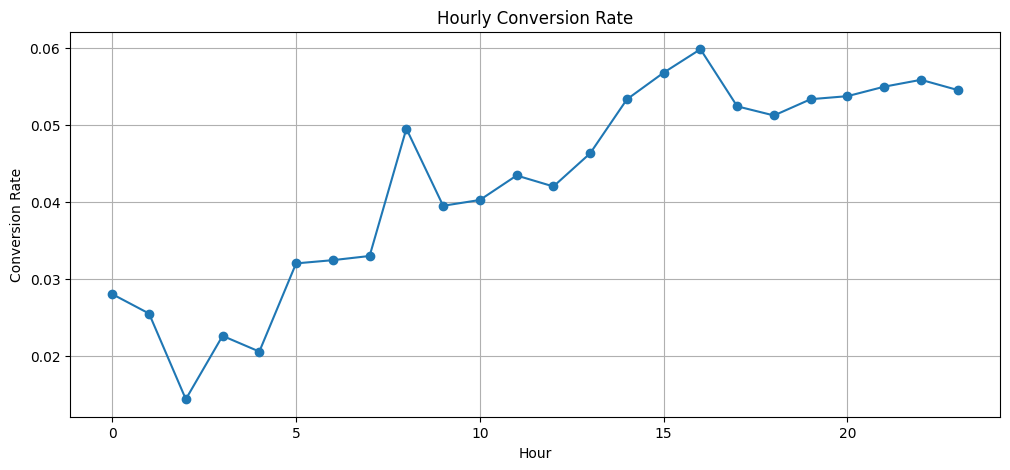

In [81]:
plt.figure(figsize=(12,5))

plt.plot(
    hourly_conversion["most_ads_hour"],
    hourly_conversion["converted_int"],
    marker="o"
)

plt.title("Hourly Conversion Rate")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate")
plt.grid(True)
plt.show()

In [82]:
peak = hourly_conversion.loc[
    hourly_conversion["converted_int"].idxmax()
]

lowest = hourly_conversion.loc[
    hourly_conversion["converted_int"].idxmin()
]

print("Peak Hour")
print(peak)
print()
print("Lowest Hour")
print(lowest)

Peak Hour
most_ads_hour    16.000000
converted_int     0.059841
Name: 16, dtype: float64

Lowest Hour
most_ads_hour    2.000000
converted_int    0.014315
Name: 2, dtype: float64


## Day × Hour Heatmap
Examine conversion patterns across days and hours to identify scheduling opportunities and anomalies.

In [83]:
heatmap_data = pd.pivot_table(
    df,
    values="converted_int",
    index="most_ads_day",
    columns="most_ads_hour",
    aggfunc="mean"
)

heatmap_data.head()

most_ads_hour,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
most_ads_day,,,,,,,,,,,,,,,,,,,,,
Friday,0.024523,0.014218,0.023041,0.013986,0.014085,0.022222,0.022727,0.031088,0.036437,0.029791,...,0.045499,0.044104,0.044686,0.039179,0.043098,0.042471,0.055305,0.059053,0.043843,0.036853
Monday,0.036900,0.043956,0.017143,0.018692,0.000000,0.046154,0.045455,0.021807,0.074928,0.057935,...,0.086433,0.083716,0.064729,0.055894,0.048701,0.059587,0.059692,0.056369,0.051458,0.101695
Saturday,0.044521,0.018051,0.010909,0.028571,0.000000,0.080645,0.068966,0.040000,0.056437,0.035714,...,0.040317,0.054222,0.045662,0.055016,0.056255,0.056502,0.049142,0.069391,0.071581,0.062921
Sunday,0.024845,0.019231,0.009009,0.014925,0.043478,0.028571,0.014925,0.044444,0.048649,0.046819,...,0.038184,0.051136,0.064639,0.070229,0.058613,0.075780,0.077728,0.083499,0.085554,0.084886
Thursday,0.030387,0.039474,0.021739,0.021978,0.037736,0.030303,0.033784,0.022599,0.037992,0.040936,...,0.047863,0.047091,0.057906,0.044195,0.043590,0.054795,0.057567,0.043702,0.050691,0.042526


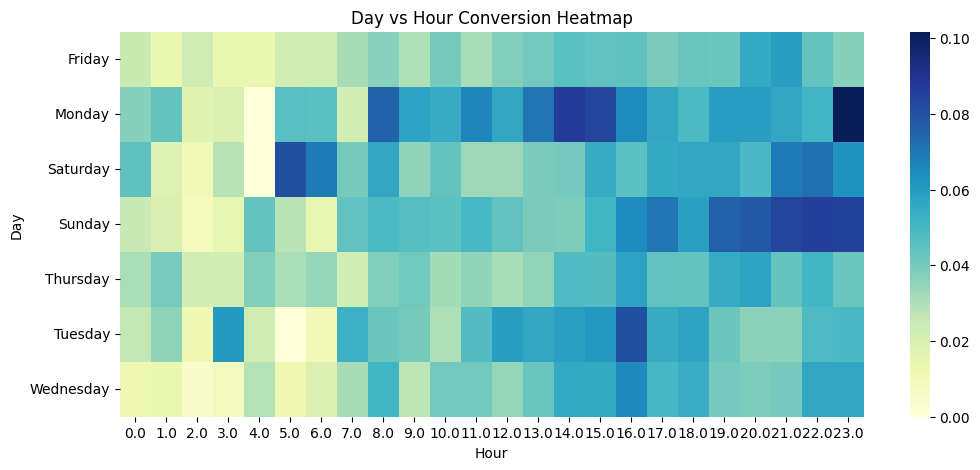

In [84]:
plt.figure(figsize=(12,5))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)
plt.title("Day vs Hour Conversion Heatmap")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

## Business Impact Calculation
Estimate the incremental conversions and business impact generated by the advertising campaign.

In [85]:
summary = df.groupby("test_group")["converted_int"].agg(
    conversions="sum",
    total="count"
)

summary["conversion_rate"] = (
    summary["conversions"] /
    summary["total"]
)

summary

,conversions,total,conversion_rate
test_group,,,
ad,7945,160243,0.049581
psa,263,8922,0.029478


In [86]:
ad_rate = summary.loc["ad", "conversion_rate"]
psa_rate = summary.loc["psa", "conversion_rate"]

lift = ad_rate - psa_rate

print("Ads Conversion Rate :", round(ad_rate,4))
print("PSA Conversion Rate :", round(psa_rate,4))
print("Incremental Lift :", round(lift,4))

Ads Conversion Rate : 0.0496
PSA Conversion Rate : 0.0295
Incremental Lift : 0.0201


In [90]:
ad_users = summary.loc["ad", "total"]
extra_conversions = lift * ad_users
print("Estimated Additional Conversions")
round(extra_conversions)

Estimated Additional Conversions


3221

In [89]:
impact = pd.DataFrame({
    "Metric":[
        "Ads Conversion Rate",
        "PSA Conversion Rate",
        "Incremental Lift",
        "Estimated Additional Conversions"
    ],
    "Value":[
        ad_rate,
        psa_rate,
        lift,
        round(extra_conversions)
    ]
})

impact

,Metric,Value
0,Ads Conversion Rate,0.049581
1,PSA Conversion Rate,0.029478
2,Incremental Lift,0.020103
3,Estimated Additional Conversions,3221.000000
